# CES Benchmark (Complex Exponential Smoothing) — smooth 1.0.9

Rerun of the CES comparison on M1 + M3 + Tourism (5,315 series) after the
backcasting rewrite on the `backcast-warmstart` branch. Same harness and settings
as the ETS benchmark: fit on `series.x`, forecast `series.h` steps, score against
`series.xx`, and report **RMSSE**, **SAME** and **computational time**.

**Only the smooth rows were recomputed** — `AutoCES` under the three
initialisations plus the four fixed-seasonality members it selects among. The
`statsforecast` and `sktime` rows are read from the saved array of the previous
full run and carried in unchanged; neither package changed. Every table carries a
`Source` column giving the run each row comes from.

**Implementations.** Only two exist: smooth's `AutoCES`/`CES` and statsforecast's
`AutoCES`. `sktime`'s `StatsForecastAutoCES` is a thin adapter around the
statsforecast routine, kept as a harness check rather than as an independent
implementation — it should reproduce the statsforecast row. `skforecast` and
`aeon` ship no CES at all.

In [1]:
import glob, os, subprocess, sys
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
HERE = os.getcwd()

SMOOTH = ["CES Back", "CES Opt", "CES Two",
          "CES none", "CES simple", "CES partial", "CES full"]
COMPETITORS = ["statsforecast AutoCES", "sktime AutoCES"]

## Versions

In [2]:
from importlib.metadata import version as pkg_version

print(f"python {sys.version.split()[0]}")
for _p in ("smooth", "numpy", "pandas", "statsforecast", "sktime", "fcompdata"):
    try:
        print(f"{_p:15s} v{pkg_version(_p)}")
    except Exception:
        print(f"{_p:15s} not installed")

print("\ngit branch / HEAD:")
for cmd in (["git", "rev-parse", "--abbrev-ref", "HEAD"], ["git", "log", "-1", "--format=%h %s"]):
    print("  " + subprocess.run(cmd, capture_output=True, text=True).stdout.strip())

python 3.14.4
smooth          v1.0.9
numpy           v2.3.5
pandas          v2.3.3
statsforecast   v2.1.1
sktime          v1.0.1
fcompdata       v0.1.4

git branch / HEAD:
  backcast-warmstart
  1ef21435 Open the v1.0.9 section in the Python NEWS


## Load Datasets

In [3]:
from fcompdata import M1, M3, Tourism

datasets = ([M1[k] for k in M1.keys()]
            + [M3[k] for k in M3.keys()]
            + [Tourism[k] for k in Tourism.keys()])
print(f"M1: {len(M1)}   M3: {len(M3)}   Tourism: {len(Tourism)}   total: {len(datasets)}")

M1: 1001   M3: 3003   Tourism: 1311   total: 5315


## Methods

The three `AutoCES` rows mirror the `ADAM ETS Back/Opt/Two` rows of the ETS
notebook; the four fixed-seasonality rows are the members `AutoCES` chooses
among. On yearly data a seasonal CES has no seasonal lag, so those rows fall back
to `seasonality="none"`, the same way the ETS notebook drops the seasonal letter
when `period == 1`.

In [4]:
from run_ces_benchmark import METHODS

for name, pkg, cfg in METHODS:
    detail = ", ".join(f"{k}={v}" for k, v in cfg.items()) or "defaults"
    mark = "rerun" if name in SMOOTH else "saved"
    print(f"  {name:24s} [{pkg:14s}] {detail:45s} {mark}")

  CES Back                 [smooth-auto   ] initial=backcasting                           rerun
  CES Opt                  [smooth-auto   ] initial=optimal                               rerun
  CES Two                  [smooth-auto   ] initial=two-stage                             rerun
  CES none                 [smooth-fixed  ] seasonality=none, initial=backcasting         rerun
  CES simple               [smooth-fixed  ] seasonality=simple, initial=backcasting       rerun
  CES partial              [smooth-fixed  ] seasonality=partial, initial=backcasting      rerun
  CES full                 [smooth-fixed  ] seasonality=full, initial=backcasting         rerun
  statsforecast AutoCES    [statsforecast ] defaults                                      saved
  sktime AutoCES           [sktime        ] defaults                                      saved


## Run or load

The heavy run lives in `run_ces_benchmark.py`, restricted to the smooth rows by
name through `BENCH_ONLY` and tagged `smooth` so it cannot overwrite the
full-roster array. Set `BENCH_RERUN_CES=1` to recompute it here.

In [5]:
if os.environ.get("BENCH_RERUN_CES", "0") == "1":
    import multiprocessing
    workers = os.environ.get("BENCH_WORKERS", str(min(20, multiprocessing.cpu_count())))
    # The method names are spelled out: a bare "ces" substring would also match
    # statsforecast AutoCES and sktime AutoCES, which are not being refitted.
    # The BLAS threads are pinned so each worker stays on one core.
    subprocess.run([sys.executable, "run_ces_benchmark.py"], check=True,
                   env=dict(os.environ, BENCH_TAG="smooth", BENCH_WORKERS=workers,
                            BENCH_ONLY=",".join(SMOOTH),
                            OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1",
                            MKL_NUM_THREADS="1"))


def newest(pattern):
    hits = sorted(glob.glob(os.path.join(HERE, pattern)), key=os.path.basename)
    if not hits:
        raise FileNotFoundError(pattern)
    return hits[-1]


rerun_file = newest("*-benchmark-ces-smooth.npy")
rerun = np.load(rerun_file)
with open(newest("*-benchmark-ces-smooth-methods.txt")) as f:
    rerun_names = [line.strip() for line in f if line.strip()]

# The previous full-roster run: it holds the competitor rows, and the smooth rows
# as they were before the backcasting rewrite.
saved_file = newest("2026-08-22-benchmark-ces.npy")
saved = np.load(saved_file)
saved_names = [m[0] for m in METHODS]

print(f"smooth rows      {os.path.basename(rerun_file)}  {rerun.shape}  {', '.join(rerun_names)}")
print(f"competitor rows  {os.path.basename(saved_file)}  {saved.shape}")
assert rerun_names == SMOOTH and saved.shape[0] == len(saved_names)

SOURCE, RESULT = {}, {}
for name in SMOOTH:
    RESULT[name], SOURCE[name] = rerun[rerun_names.index(name)], os.path.basename(rerun_file)[:10]
for name in COMPETITORS:
    RESULT[name], SOURCE[name] = saved[saved_names.index(name)], os.path.basename(saved_file)[:10]

# Guard against scoring a stale rerun.
SRC = os.path.abspath(os.path.join(HERE, "..", "..", "src", "smooth"))
newest_source = max(os.path.getmtime(os.path.join(folder, f))
                    for folder, _, files in os.walk(SRC) for f in files if f.endswith(".py"))
stale = os.path.getmtime(rerun_file) < newest_source
print("\nsmooth arrays postdate the smooth sources:", not stale)
assert not stale, "rerun the smooth rows: BENCH_RERUN_CES=1"

ALL = SMOOTH + COMPETITORS
print("\nPer-method summary:")
for name in ALL:
    r = RESULT[name]
    print(f"  {name:24s} [{SOURCE[name]}]  RMSSE={np.nanmean(r[:, 0]):.4f}  "
          f"SAME={np.nanmean(r[:, 1]):.4f}  Time={np.nanmean(r[:, 2]):.3f}s  "
          f"Failed={int(np.sum(np.isnan(r[:, 0])))}")

smooth rows      2026-09-24-benchmark-ces-smooth.npy  (7, 5315, 3)  CES Back, CES Opt, CES Two, CES none, CES simple, CES partial, CES full
competitor rows  2026-08-22-benchmark-ces.npy  (9, 5315, 3)

smooth arrays postdate the smooth sources: True

Per-method summary:
  CES Back                 [2026-09-24]  RMSSE=2.0784  SAME=1.9998  Time=0.108s  Failed=0
  CES Opt                  [2026-09-24]  RMSSE=2.1179  SAME=2.0480  Time=0.658s  Failed=0
  CES Two                  [2026-09-24]  RMSSE=2.1126  SAME=2.0398  Time=0.719s  Failed=0
  CES none                 [2026-09-24]  RMSSE=2.1450  SAME=2.1269  Time=0.017s  Failed=0
  CES simple               [2026-09-24]  RMSSE=2.3910  SAME=2.3364  Time=0.018s  Failed=0
  CES partial              [2026-09-24]  RMSSE=2.0854  SAME=1.9954  Time=0.027s  Failed=0
  CES full                 [2026-09-24]  RMSSE=2.0927  SAME=2.0049  Time=0.036s  Failed=0
  statsforecast AutoCES    [2026-08-22]  RMSSE=1.9573  SAME=1.9978  Time=0.007s  Failed=0
  sktime A

## Results Summary

In [6]:
def summary(metric, label, time_column="Mean Time (s)"):
    frame = pd.DataFrame({
        "Method": ALL,
        "Source": [SOURCE[n] for n in ALL],
        "Min": [np.nanmin(RESULT[n][:, metric]) for n in ALL],
        "Q1": [np.nanquantile(RESULT[n][:, metric], 0.25) for n in ALL],
        "Med": [np.nanmedian(RESULT[n][:, metric]) for n in ALL],
        "Q3": [np.nanquantile(RESULT[n][:, metric], 0.75) for n in ALL],
        "Max": [np.nanmax(RESULT[n][:, metric]) for n in ALL],
        "Mean": [np.nanmean(RESULT[n][:, metric]) for n in ALL],
        time_column: [np.nanmean(RESULT[n][:, 2]) for n in ALL],
        "Failed": [int(np.sum(np.isnan(RESULT[n][:, metric]))) for n in ALL],
    })
    print("\n" + "=" * 110 + f"\nEVALUATION RESULTS for {label} (all series)\n" + "=" * 110)
    print(frame.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return frame


summary_rmsse = summary(0, "RMSSE")


EVALUATION RESULTS for RMSSE (all series)
               Method     Source    Min     Q1    Med     Q3     Max   Mean  Mean Time (s)  Failed
             CES Back 2026-09-24 0.0248 0.8268 1.3655 2.3946 51.2724 2.0784         0.1078       0
              CES Opt 2026-09-24 0.0249 0.8552 1.3922 2.4082 49.1350 2.1179         0.6576       0
              CES Two 2026-09-24 0.0248 0.8501 1.3898 2.4125 51.1779 2.1126         0.7187       0
             CES none 2026-09-24 0.0248 0.8889 1.4174 2.4857 51.2724 2.1450         0.0173       0
           CES simple 2026-09-24 0.0462 0.9465 1.5385 2.7923 51.2724 2.3910         0.0184       0
          CES partial 2026-09-24 0.0500 0.8487 1.3677 2.3977 51.2724 2.0854         0.0270       0
             CES full 2026-09-24 0.0470 0.8461 1.3819 2.4344 51.2724 2.0927         0.0355       0
statsforecast AutoCES 2026-08-22 0.0449 0.6781 1.1672 2.2861 50.6247 1.9573         0.0069       0
       sktime AutoCES 2026-08-22 0.0449 0.6781 1.1672 2.2861 50.62

In [7]:
summary_same = summary(1, "SAME")


EVALUATION RESULTS for SAME (all series)
               Method     Source    Min     Q1    Med     Q3     Max   Mean  Mean Time (s)  Failed
             CES Back 2026-09-24 0.0001 0.3860 1.0146 2.4122 54.9071 1.9998         0.1078       0
              CES Opt 2026-09-24 0.0003 0.4048 1.0304 2.4458 54.8930 2.0480         0.6576       0
              CES Two 2026-09-24 0.0002 0.4097 1.0265 2.4504 54.8883 2.0398         0.7187       0
             CES none 2026-09-24 0.0013 0.4541 1.1819 2.6163 54.9071 2.1269         0.0173       0
           CES simple 2026-09-24 0.0002 0.4400 1.1433 2.7897 54.9071 2.3364         0.0184       0
          CES partial 2026-09-24 0.0001 0.3770 1.0146 2.4298 54.9071 1.9954         0.0270       0
             CES full 2026-09-24 0.0002 0.3797 1.0198 2.4436 54.9071 2.0049         0.0355       0
statsforecast AutoCES 2026-08-22 0.0004 0.3706 1.0009 2.3995 54.8929 1.9978         0.0069       0
       sktime AutoCES 2026-08-22 0.0004 0.3706 1.0009 2.3995 54.892

In [8]:
summary_time = pd.DataFrame({
    "Method": ALL,
    "Source": [SOURCE[n] for n in ALL],
    "Min": [np.nanmin(RESULT[n][:, 2]) for n in ALL],
    "Med": [np.nanmedian(RESULT[n][:, 2]) for n in ALL],
    "Max": [np.nanmax(RESULT[n][:, 2]) for n in ALL],
    "Mean": [np.nanmean(RESULT[n][:, 2]) for n in ALL],
    "Total (min)": [np.nansum(RESULT[n][:, 2]) / 60 for n in ALL],
})
print("\n" + "=" * 110 + "\nEVALUATION RESULTS for computational time in seconds (all series)\n" + "=" * 110)
print(summary_time.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


EVALUATION RESULTS for computational time in seconds (all series)
               Method     Source    Min    Med    Max   Mean  Total (min)
             CES Back 2026-09-24 0.0086 0.1108 1.1675 0.1078       9.5499
              CES Opt 2026-09-24 0.0186 0.4690 2.2386 0.6576      58.2523
              CES Two 2026-09-24 0.0245 0.5203 2.4888 0.7187      63.6609
             CES none 2026-09-24 0.0090 0.0156 0.0567 0.0173       1.5322
           CES simple 2026-09-24 0.0093 0.0169 0.0572 0.0184       1.6283
          CES partial 2026-09-24 0.0087 0.0254 0.0962 0.0270       2.3941
             CES full 2026-09-24 0.0089 0.0356 0.1303 0.0355       3.1473
statsforecast AutoCES 2026-08-22 0.0001 0.0033 0.5633 0.0069       0.6118
       sktime AutoCES 2026-08-22 0.0048 0.0107 0.7397 0.0149       1.3229


## Change against the previous smooth run

The saved array holds the same seven smooth rows as they were before the
backcasting rewrite, measured on exactly the same series.

In [9]:
rows = []
for name in SMOOTH:
    before, after = saved[saved_names.index(name)], RESULT[name]
    rows.append({
        "Method": name,
        "Med RMSSE before": np.nanmedian(before[:, 0]),
        "Med RMSSE after": np.nanmedian(after[:, 0]),
        "Mean RMSSE before": np.nanmean(before[:, 0]),
        "Mean RMSSE after": np.nanmean(after[:, 0]),
        "Mean SAME before": np.nanmean(before[:, 1]),
        "Mean SAME after": np.nanmean(after[:, 1]),
        "Mean time before": np.nanmean(before[:, 2]),
        "Mean time after": np.nanmean(after[:, 2]),
        "Series changed": int(np.sum(~np.isclose(before[:, 0], after[:, 0], equal_nan=True))),
    })
print(f"\nbefore = {os.path.basename(saved_file)[:10]}   after = {os.path.basename(rerun_file)[:10]}")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:.4f}"))


before = 2026-08-22   after = 2026-09-24
     Method  Med RMSSE before  Med RMSSE after  Mean RMSSE before  Mean RMSSE after  Mean SAME before  Mean SAME after  Mean time before  Mean time after  Series changed
   CES Back            1.3762           1.3655             2.0997            2.0784            2.0227           1.9998            0.2572           0.1078            5294
    CES Opt            1.3976           1.3922             2.1174            2.1179            2.0474           2.0480            1.0171           0.6576             662
    CES Two            1.3928           1.3898             2.1216            2.1126            2.0525           2.0398            1.2393           0.7187            5193
   CES none            1.4249           1.4174             2.1569            2.1450            2.1400           2.1269            0.0283           0.0173            5216
 CES simple            1.5566           1.5385             2.4058            2.3910            2.3350       

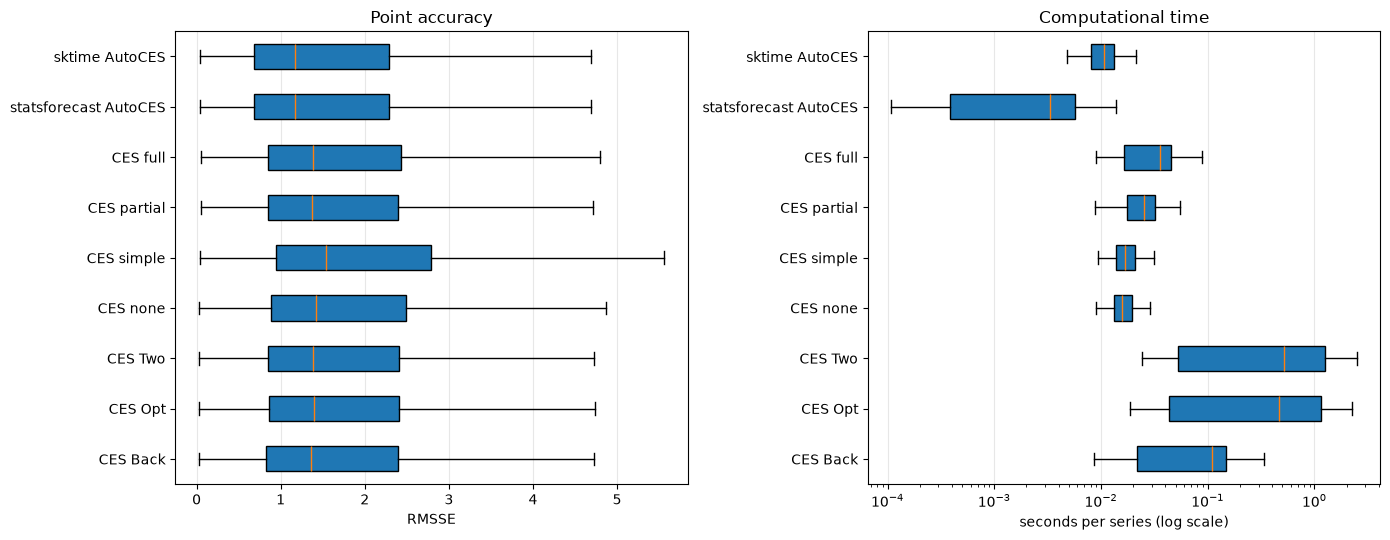

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
order = ALL
ax[0].boxplot([RESULT[n][:, 0][np.isfinite(RESULT[n][:, 0])] for n in order],
              orientation="horizontal", tick_labels=order, showfliers=False, patch_artist=True)
ax[1].boxplot([RESULT[n][:, 2][np.isfinite(RESULT[n][:, 2])] for n in order],
              orientation="horizontal", tick_labels=order, showfliers=False, patch_artist=True)
ax[0].set(xlabel="RMSSE", title="Point accuracy")
ax[1].set(xscale="log", xlabel="seconds per series (log scale)", title="Computational time")
for a in ax:
    a.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()